# Signal Disentanglement — CNN vs Authenticator Memorisation

The standard pipeline trains both the CNN encoder and the authentication LSTM on the same subjects, so any membership signal could come from either component. This notebook analyses the `whuGAIT_signal` run, which assigns subjects to three non-overlapping groups to separate the two contributions:

| Group | Subjects | CNN trained | Auth trained | Role |
|-------|----------|-------------|--------------|------|
| A | 21–40 | yes | no | isolates CNN memorisation |
| B | 41–60 | no | yes | isolates authenticator memorisation |
| C | 1–20  | no | no | held-out baseline |

Three figures are produced:
1. **Auth model performance per group** — how well the authenticator discriminates same-person from different-person pairs for subjects it was trained on (B), subjects the CNN knows (A), and subjects neither model saw (C).
2. **MIA attack score per group** — for each attack variant, the mean percentile rank of subjects in each group, showing whether B and A sit above the held-out baseline C.
3. **ROC curves per group comparison** — full ROC curves for the B-vs-C and A-vs-C attack settings across all four attack variants.

In [15]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, auc as sk_auc, accuracy_score
from scipy.special import logit as scipy_logit

sys.path.insert(0, '../..')

import torch
from src.models.gait_cnn   import GaitCNN
from src.models.auth_model import AuthModel
from src.utils.config_loader import dataset_dirs, dataset_files

DATASET      = 'whuGAIT_signal'
ARTIFACT_DIR = Path('../../artifacts') / DATASET
OUT_DIR      = Path('../../results/analysis')
TEX_DIR      = Path('../../latex/generated')
OUT_DIR.mkdir(parents=True, exist_ok=True)
TEX_DIR.mkdir(parents=True, exist_ok=True)

_dirs = dataset_dirs(
    Path('../../logs'), Path('../../checkpoints'),
    artifacts_base=Path('../../artifacts'), dataset=DATASET,
)
PATHS = dataset_files(_dirs['logs'], _dirs['checkpoints'], artifacts_dir=_dirs['artifacts'])

# Group definitions
CNN_IDS  = list(range(21, 41))
AUTH_IDS = list(range(41, 61))
HELD_IDS = list(range(1,  21))
CNN_SET  = set(CNN_IDS)
AUTH_SET = set(AUTH_IDS)
HELD_SET = set(HELD_IDS)

DEVICE = torch.device('cpu')
BATCH  = 256

GROUP_COLORS = {
    'A (CNN, 21–40)':    '#3498db',
    'B (auth, 41–60)':   '#2ecc71',
    'C (held-out, 1–20)':'#e74c3c',
}
GROUP_LABELS = list(GROUP_COLORS.keys())

print(f'Artefact dir: {ARTIFACT_DIR}')
print(f'Auth checkpoint: {PATHS["auth_ckpt"]}')

Artefact dir: ../../artifacts/whuGAIT_signal
Auth checkpoint: ../../checkpoints/whuGAIT_signal/auth_model.pt


## 1. Auth Model Performance per Group

The authenticator was trained on Group B pairs. If it has memorised those subjects, it should discriminate same-person from different-person pairs better for Group B than for the two groups it never saw. The comparison between Group A and Group C also shows whether the CNN's prior representation of Group A subjects carries any benefit for the authenticator.

In [16]:
# Load auth model
with open(PATHS['cnn_meta']) as f:
    cnn_n = json.load(f)['n_classes']
cnn   = GaitCNN(n_classes=cnn_n).to(DEVICE)
model = AuthModel(cnn).to(DEVICE)
model.load_state_dict(torch.load(PATHS['auth_ckpt'], map_location=DEVICE))
model.eval()
print(f'Auth model loaded  (CNN n_classes={cnn_n})')

# Load normalisation stats and auth_pairs
norm_data  = np.load(PATHS['norm_stats'])
norm_mean  = norm_data['mean']
norm_std   = norm_data['std']
pairs      = np.load(ARTIFACT_DIR / 'auth_pairs.npz')

def normalise(X):
    return (X - norm_mean) / (norm_std + 1e-8)

def score_pairs(X1, X2):
    """Return P(different person) for each pair."""
    X1n, X2n = normalise(X1), normalise(X2)
    scores = []
    with torch.no_grad():
        for i in range(0, len(X1n), BATCH):
            b1 = torch.from_numpy(X1n[i:i+BATCH]).float().to(DEVICE)
            b2 = torch.from_numpy(X2n[i:i+BATCH]).float().to(DEVICE)
            scores.append(model.similarity(b1, b2).cpu().numpy())
    return np.concatenate(scores)

# Group B: in-sample auth eval (separate seed from training)
X1_b = pairs['X1_auth_eval'];  X2_b = pairs['X2_auth_eval']
y_b  = pairs['y_auth_eval'];   s1_b = pairs['subj1_auth_eval']
sc_b = score_pairs(X1_b, X2_b)

# Group A + C: test split; split by subject ID
X1_te  = pairs['X1_te'];  X2_te = pairs['X2_te']
y_te   = pairs['y_te'];   s1_te = pairs['subj1_te']
sc_te  = score_pairs(X1_te, X2_te)

mask_a = np.array([s in CNN_SET  for s in s1_te])
mask_c = np.array([s in HELD_SET for s in s1_te])

groups_auth = {
    'A (CNN, 21–40)':    (sc_te[mask_a], y_te[mask_a]),
    'B (auth, 41–60)':   (sc_b,          y_b),
    'C (held-out, 1–20)': (sc_te[mask_c], y_te[mask_c]),
}

auth_results = {}
for grp, (sc, y) in groups_auth.items():
    # y=0 same person, y=1 different person; high score = predict different
    auc  = roc_auc_score(y, sc)
    acc  = accuracy_score(y, (sc >= 0.5).astype(int))
    auth_results[grp] = {'auc': auc, 'acc': acc, 'n': len(y)}
    print(f'{grp:25s}  n={len(y):5d}  acc={acc*100:.1f}%  AUC={auc:.3f}')

Auth model loaded  (CNN n_classes=20)
A (CNN, 21–40)             n= 1000  acc=81.2%  AUC=0.860
B (auth, 41–60)            n= 1000  acc=80.2%  AUC=0.881
C (held-out, 1–20)         n= 1000  acc=73.7%  AUC=0.832


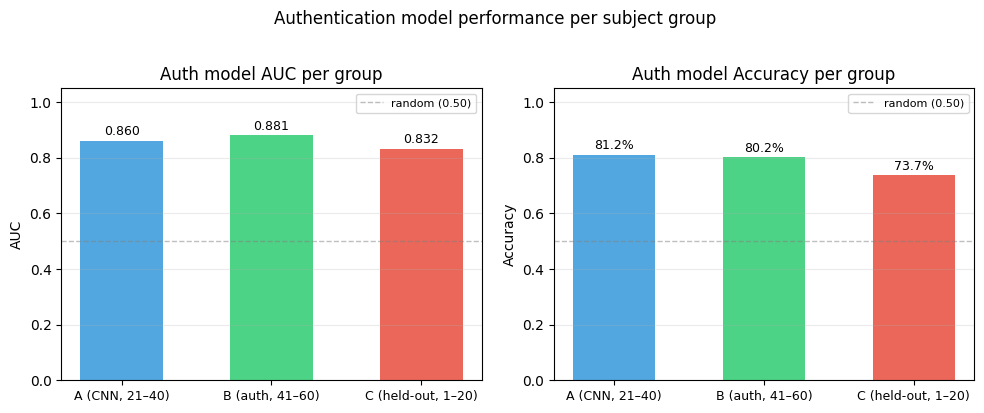

Saved: signal_auth_performance.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

grp_labels = list(auth_results.keys())
colors     = [GROUP_COLORS[g] for g in grp_labels]
x          = np.arange(len(grp_labels))

for ax, (key, ylabel, fmt) in zip(axes, [
    ('auc',  'AUC',         '.3f'),
    ('acc',  'Accuracy',    '.1%'),
]):
    vals = [auth_results[g][key] for g in grp_labels]
    bars = ax.bar(x, vals, color=colors, alpha=0.85, width=0.55)
    ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.5, label='random (0.50)')
    ax.set_xticks(x)
    ax.set_xticklabels(grp_labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Auth model {ylabel} per group')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                format(val, fmt), ha='center', va='bottom', fontsize=9)

plt.suptitle('Authentication model performance per subject group', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'signal_auth_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: signal_auth_performance.png')

## 2. MIA Attack Score per Group

The attack assigns a per-subject score: higher means the model predicts that subject was a training member. Group B (authenticator's training subjects) should score highest if the LSTM memorised them; Group A (CNN's training subjects) should sit above the held-out baseline if the CNN encoder contributes a separate signal; Group C is the baseline that neither model saw.

Each bar shows the mean percentile rank of that group's 20 subjects, computed by ranking all 60 subjects by their attack score. Random assignment would give a mean rank of 0.33 for each group (since each group is one-third of 60). A mean rank well above 0.33 for a group means the attack consistently scores those subjects near the top.

In [18]:
# Simple delta per-group AUCs from NB04 (kept for ROC curves in Figure 3)
g = np.load(ARTIFACT_DIR / '04_signal_groups.npz')
simple_d = {
    'B vs C': float(g['auc_auth_vs_held']),
    'A vs C': float(g['auc_cnn_vs_held']),
}

# Per-subject delta scores from NB04
nb04 = np.load(ARTIFACT_DIR / '04_mia_scores.npz')
m_ids  = nb04['member_ids'].tolist()     # auth group (41-60)
nm_ids = nb04['nonmember_ids'].tolist()  # CNN (21-40) + held-out (1-20)
m_sc   = dict(zip(m_ids,  nb04['member_scores']))
nm_sc  = dict(zip(nm_ids, nb04['nonmember_scores']))
all_sc = {**m_sc, **nm_sc}

# LiRA-raw per-subject scores from NB05b
with open(ARTIFACT_DIR / '05b_per_subject_report.json') as f:
    rep = json.load(f)
ps = {r['subject_id']: r for r in rep['per_subject']}

# BB-warm / BB-cold: use IN - mean(OUT) as LiRA proxy
nb05a = np.load(ARTIFACT_DIR / '05a_target_deltas.npz')
in_scores = {**dict(zip(nb05a['member_ids'],    nb05a['member_raw'])),
             **dict(zip(nb05a['nonmember_ids'],  nb05a['nonmember_raw']))}

def shadow_lira_scores(shadow_path):
    with open(shadow_path) as f:
        d = json.load(f)
    out = {}
    for sid_str, out_list in d['raw'].items():
        sid = int(sid_str)
        if sid in in_scores:
            out[sid] = float(in_scores[sid]) - float(np.mean(out_list))
    return out

warm_sc = shadow_lira_scores(ARTIFACT_DIR / f'05c_lira_warm_shadows_{DATASET}.json')
cold_sc = shadow_lira_scores(ARTIFACT_DIR / f'05c_lira_cold_shadows_{DATASET}.json')

# --- Per-group mean percentile rank ---
ALL_IDS = CNN_IDS + AUTH_IDS + HELD_IDS  # all 60 subjects

def mean_rank_per_group(sc_dict):
    """Rank all subjects by score, return mean percentile rank for A, B, C."""
    sids = [s for s in ALL_IDS if s in sc_dict]
    scores_all = np.array([sc_dict[s] for s in sids])
    # percentile rank: rank 1 = lowest score, rank N = highest; normalise to [0,1]
    ranks = scores_all.argsort().argsort() / (len(sids) - 1)
    rank_map = dict(zip(sids, ranks))
    ra = np.mean([rank_map[s] for s in CNN_IDS  if s in rank_map])
    rb = np.mean([rank_map[s] for s in AUTH_IDS if s in rank_map])
    rc = np.mean([rank_map[s] for s in HELD_IDS if s in rank_map])
    return ra, rb, rc

lira_sc = {s: ps[s]['LiRA-raw']['score'] for s in ALL_IDS if s in ps}

group_ranks = {
    'Simple-δ':        mean_rank_per_group(all_sc),
    'LiRA-raw (grey)': mean_rank_per_group(lira_sc),
    'BB-warm':         mean_rank_per_group(warm_sc),
    'BB-cold':         mean_rank_per_group(cold_sc),
}

print('Mean percentile rank per group (0=lowest scorer, 1=highest):')
print(f'{"":22s}  {"Group A":>8}  {"Group B":>8}  {"Group C":>8}')
for var, (ra, rb, rc) in group_ranks.items():
    print(f'{var:22s}  {ra:.4f}    {rb:.4f}    {rc:.4f}')

# Keep pairwise AUCs for ROC curves (Figure 3)
comp_groups = {
    'B vs C': (AUTH_IDS, HELD_IDS),
    'A vs C': (CNN_IDS,  HELD_IDS),
}

def gauc_dict(sc_dict, ga, gb):
    rows = [(1, sc_dict[s]) for s in ga if s in sc_dict] + \
           [(0, sc_dict[s]) for s in gb if s in sc_dict]
    return roc_auc_score([r[0] for r in rows], [r[1] for r in rows])

def gauc_ps(ga, gb, score_key):
    rows = [(sid, 1, ps[sid][score_key]['score']) for sid in ga if sid in ps] + \
           [(sid, 0, ps[sid][score_key]['score']) for sid in gb if sid in ps]
    return roc_auc_score([r[1] for r in rows], [r[2] for r in rows])

roc_aucs = {
    'Simple-δ':        {c: gauc_dict(all_sc,   *comp_groups[c]) for c in comp_groups},
    'LiRA-raw (grey)': {c: gauc_ps(*comp_groups[c], 'LiRA-raw') for c in comp_groups},
    'BB-warm':         {c: gauc_dict(warm_sc,  *comp_groups[c]) for c in comp_groups},
    'BB-cold':         {c: gauc_dict(cold_sc,  *comp_groups[c]) for c in comp_groups},
}

Mean percentile rank per group (0=lowest scorer, 1=highest):
                         Group A   Group B   Group C
Simple-δ                0.5568    0.5559    0.3873
LiRA-raw (grey)         0.4737    0.5610    0.4653
BB-warm                 0.4966    0.5729    0.4305
BB-cold                 0.5568    0.5542    0.3890


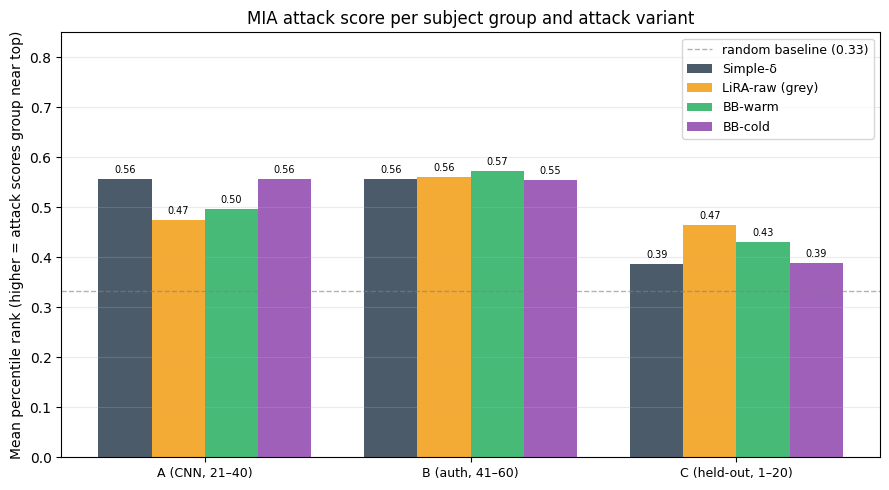

Saved: signal_mia_auc_per_group.png


In [19]:
VAR_COLORS = {
    'Simple-δ':        '#2c3e50',
    'LiRA-raw (grey)': '#f39c12',
    'BB-warm':         '#27ae60',
    'BB-cold':         '#8e44ad',
}

group_keys   = ['A (CNN, 21–40)', 'B (auth, 41–60)', 'C (held-out, 1–20)']
group_colors = [GROUP_COLORS[g] for g in group_keys]
var_names    = list(group_ranks.keys())
n_grp        = len(group_keys)
n_var        = len(var_names)
x            = np.arange(n_grp)
w            = 0.8 / n_var

fig, ax = plt.subplots(figsize=(9, 5))
for i, var in enumerate(var_names):
    ra, rb, rc = group_ranks[var]
    vals   = [ra, rb, rc]
    offset = (i - n_var / 2 + 0.5) * w
    bars   = ax.bar(x + offset, vals, w, label=var,
                    color=VAR_COLORS[var], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

ax.axhline(1/3, color='grey', ls='--', lw=1, alpha=0.6, label='random baseline (0.33)')
ax.set_xticks(x)
ax.set_xticklabels(group_keys, fontsize=9)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Mean percentile rank (higher = attack scores group near top)')
ax.set_title('MIA attack score per subject group and attack variant')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'signal_mia_auc_per_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: signal_mia_auc_per_group.png')

## 3. ROC Curves per Group Comparison

Each panel shows the full ROC for one real-attack comparison: B vs C (authenticator members vs held-out) and A vs C (CNN members vs held-out). The gap between the two curves, if present, indicates how much the authenticator's memorisation signal exceeds the CNN encoder's contribution alone.

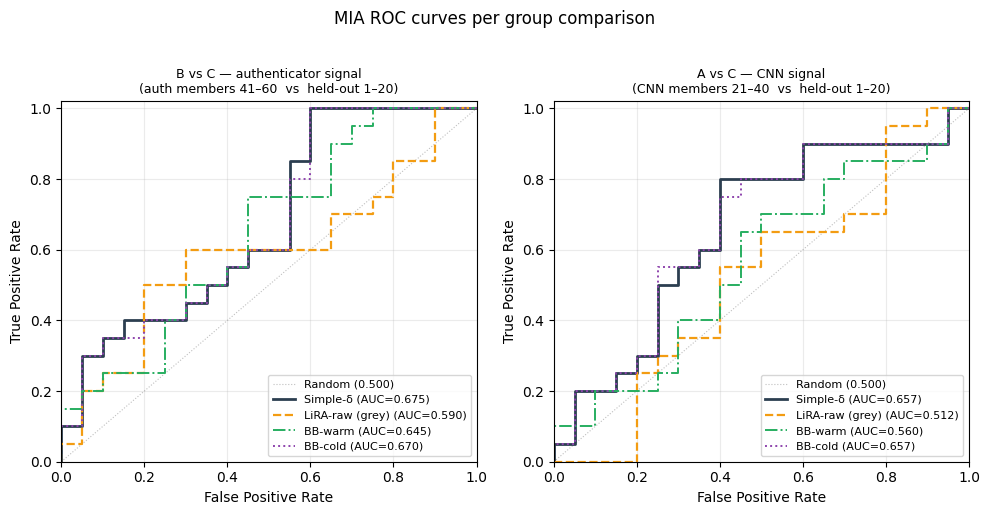

Saved: signal_roc_per_group.png


In [20]:
def roc_from_dict(sc_dict, ga, gb):
    rows = [(1, sc_dict[s]) for s in ga if s in sc_dict] + \
           [(0, sc_dict[s]) for s in gb if s in sc_dict]
    ys = [r[0] for r in rows]
    sc = [r[1] for r in rows]
    fpr, tpr, _ = roc_curve(ys, sc)
    return fpr, tpr, sk_auc(fpr, tpr)

def roc_from_ps(ps_dict, ga, gb, key):
    rows = [(1, ps_dict[s][key]['score']) for s in ga if s in ps_dict] + \
           [(0, ps_dict[s][key]['score']) for s in gb if s in ps_dict]
    ys = [r[0] for r in rows]
    sc = [r[1] for r in rows]
    fpr, tpr, _ = roc_curve(ys, sc)
    return fpr, tpr, sk_auc(fpr, tpr)

ATTACK_LINES = [
    ('Simple-δ',        '#2c3e50', 2.0, '-'),
    ('LiRA-raw (grey)', '#f39c12', 1.6, '--'),
    ('BB-warm',         '#27ae60', 1.4, '-.'),
    ('BB-cold',         '#8e44ad', 1.4, ':'),
]

PANELS = [
    ('B vs C', (AUTH_IDS, HELD_IDS), 'B vs C — authenticator signal\n(auth members 41–60  vs  held-out 1–20)'),
    ('A vs C', (CNN_IDS,  HELD_IDS), 'A vs C — CNN signal\n(CNN members 21–40  vs  held-out 1–20)'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (comp, (ga, gb), title) in zip(axes, PANELS):
    ax.plot([0, 1], [0, 1], color='grey', lw=0.8, ls=':', alpha=0.5, label='Random (0.500)')

    for var, color, lw, ls in ATTACK_LINES:
        if var == 'Simple-δ':
            fpr, tpr, a = roc_from_dict(all_sc, ga, gb)
        elif var == 'LiRA-raw (grey)':
            fpr, tpr, a = roc_from_ps(ps, ga, gb, 'LiRA-raw')
        elif var == 'BB-warm':
            fpr, tpr, a = roc_from_dict(warm_sc, ga, gb)
        else:  # BB-cold
            fpr, tpr, a = roc_from_dict(cold_sc, ga, gb)
        ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{var} (AUC={a:.3f})')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.25)

plt.suptitle('MIA ROC curves per group comparison', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'signal_roc_per_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: signal_roc_per_group.png')

In [21]:
print('=== Signal Disentanglement Summary ===')
print()
print('Auth model performance per group:')
for grp, r in auth_results.items():
    print(f'  {grp:25s}  n={r["n"]:5d}  acc={r["acc"]*100:.1f}%  AUC={r["auc"]:.3f}')
print()
print('MIA mean percentile rank per group:')
print(f'  {"":22s}  {"A":>6}  {"B":>6}  {"C":>6}')
for var, (ra, rb, rc) in group_ranks.items():
    print(f'  {var:22s}  {ra:.3f}   {rb:.3f}   {rc:.3f}')
print()
bvc = roc_aucs['Simple-δ']['B vs C']; avc = roc_aucs['Simple-δ']['A vs C']
print(f'AUC (B vs C) = {bvc:.3f}   AUC (A vs C) = {avc:.3f}   diff = {bvc - avc:+.3f}')

# Write LaTeX metrics — key_prefix='signal' prefixes every command with \signal...
# Keys must have no underscores and correct capitalisation to match preamble commands.
from src.utils.latex_writer import write_latex_metrics
metrics = {
    'authModelAUCB':  f'{auth_results["B (auth, 41–60)"]["auc"]:.3f}',
    'authModelAUCA':  f'{auth_results["A (CNN, 21–40)"]["auc"]:.3f}',
    'authModelAUCC':  f'{auth_results["C (held-out, 1–20)"]["auc"]:.3f}',
    'miaAUCBvsC':     f'{roc_aucs["Simple-δ"]["B vs C"]:.4f}',
    'miaAUCAvsC':     f'{roc_aucs["Simple-δ"]["A vs C"]:.4f}',
    'miaAUCBvsCLira': f'{roc_aucs["LiRA-raw (grey)"]["B vs C"]:.4f}',
    'miaAUCAvsCLira': f'{roc_aucs["LiRA-raw (grey)"]["A vs C"]:.4f}',
    'miaAUCBvsCCold': f'{roc_aucs["BB-cold"]["B vs C"]:.4f}',
    'miaAUCAvsCCold': f'{roc_aucs["BB-cold"]["A vs C"]:.4f}',
}
write_latex_metrics('signal_disentanglement', metrics, output_dir=str(TEX_DIR), key_prefix='signal')
print(f'LaTeX metrics written to {TEX_DIR}/signal_disentanglement_metrics.tex')

=== Signal Disentanglement Summary ===

Auth model performance per group:
  A (CNN, 21–40)             n= 1000  acc=81.2%  AUC=0.860
  B (auth, 41–60)            n= 1000  acc=80.2%  AUC=0.881
  C (held-out, 1–20)         n= 1000  acc=73.7%  AUC=0.832

MIA mean percentile rank per group:
                               A       B       C
  Simple-δ                0.557   0.556   0.387
  LiRA-raw (grey)         0.474   0.561   0.465
  BB-warm                 0.497   0.573   0.431
  BB-cold                 0.557   0.554   0.389

AUC (B vs C) = 0.675   AUC (A vs C) = 0.657   diff = +0.018
LaTeX metrics written: ../../latex/generated/signal_disentanglement_metrics.tex
LaTeX metrics written to ../../latex/generated/signal_disentanglement_metrics.tex
